<a href="https://colab.research.google.com/github/salihawouda2003/renal-transcriptomic-analysis/blob/main/renal_transcriptomic_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [19]:
# Install library
!pip install GEOparse

# Imports
import GEOparse
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

In [20]:
# Download the kidney transplant dataset (GSE36059)
gse = GEOparse.get_GEO(geo="GSE36059", destdir="./")

12-Apr-2026 20:05:57 DEBUG utils - Directory ./ already exists. Skipping.
DEBUG:GEOparse:Directory ./ already exists. Skipping.
12-Apr-2026 20:05:57 INFO GEOparse - File already exist: using local version.
INFO:GEOparse:File already exist: using local version.
12-Apr-2026 20:05:57 INFO GEOparse - Parsing ./GSE36059_family.soft.gz: 
INFO:GEOparse:Parsing ./GSE36059_family.soft.gz: 
12-Apr-2026 20:05:57 DEBUG GEOparse - DATABASE: GeoMiame
DEBUG:GEOparse:DATABASE: GeoMiame
12-Apr-2026 20:05:57 DEBUG GEOparse - SERIES: GSE36059
DEBUG:GEOparse:SERIES: GSE36059
12-Apr-2026 20:05:57 DEBUG GEOparse - PLATFORM: GPL570
DEBUG:GEOparse:PLATFORM: GPL570
/usr/local/lib/python3.12/dist-packages/GEOparse/GEOparse.py:401: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.
  return read_csv(StringIO(data), index_col=None, sep="\t")
12-Apr-2026 20:05:59 DEBUG GEOparse - SAMPLE: GSM880204
DEBUG:GEOparse:SAMPLE: GSM880204
12-Apr-2026 20:05:59 DEBUG GEOparse 

In [21]:
# Create the expression matrix (to define 'data')
data = gse.pivot_samples('VALUE')

In [27]:
# Priority-Based Mapping
sample_names = list(data.columns)
labels_final = []

for sn in sample_names:
    gsm = gse.gsms[sn]
    # Focus only on the diagnosis line
    diag_line = gsm.metadata['characteristics_ch1'][0].lower()

    # Logic: If 'non-rejecting' is the ONLY thing at the end of the string
    if diag_line.endswith('non-rejecting') or diag_line.endswith('stable'):
        labels_final.append('Stable')
    # If it ends with any of our rejection types
    elif any(diag_line.endswith(t) for t in ['tcmr', 'abmr', 'mixed', 'rejection']):
        labels_final.append('Rejection')
    else:
        # If we can't be sure, let's look for the presence of the code
        if 'non-rejecting' in diag_line:
             # Double check: does it say "diagnosis: tcmr" but mentions "non-rejecting" in the header?
             if 'diagnosis: tcmr' in diag_line or 'diagnosis: abmr' in diag_line:
                 labels_final.append('Rejection')
             else:
                 labels_final.append('Stable')
        else:
            labels_final.append('Other')

# Update global labels
labels = labels_final

# Final Clean
clean_data = data.dropna()

print("--- The Dataset Stats ---")
print(f"Rejection Samples: {labels.count('Rejection')}")
print(f"Stable Samples:    {labels.count('Stable')}")
print(f"Other/Excluded:    {labels.count('Other')}")

--- The Corrected Dataset Stats ---
Rejection Samples: 122
Stable Samples:    289
Other/Excluded:    0


In [28]:
# Identify indices for each group using the actual column names
# use the columns of clean_data to ensure perfect alignment
rejection_idx = [i for i, label in enumerate(labels) if label == 'Rejection']
stable_idx = [i for i, label in enumerate(labels) if label == 'Stable']

# SAFETY CHECK: Print counts to ensure there are samples in both groups
print(f"Samples in Rejection group: {len(rejection_idx)}")
print(f"Samples in Stable group: {len(stable_idx)}")

# Calculate means using the specific indices
# use .iloc to select columns by their integer position
mean_rejection = clean_data.iloc[:, rejection_idx].mean(axis=1)
mean_stable = clean_data.iloc[:, stable_idx].mean(axis=1)

# Calculate Log2 Fold Change
log2_fc = mean_rejection - mean_stable

# Extract Top 50 and drop any remaining NaNs
top_50_genes = log2_fc.dropna().sort_values(ascending=False).head(50)

print("\n--- TOP 10 BIOMARKERS IDENTIFIED ---")
if top_50_genes.empty:
    print("Warning: Top 50 list is empty. Check if labels match data columns.")
else:
    print(top_50_genes.head(10))

Samples in Rejection group: 122
Samples in Stable group: 289

--- TOP 10 BIOMARKERS IDENTIFIED ---
ID_REF
211122_s_at    2.739844
210163_at      2.382206
203915_at      2.286595
204533_at      2.049447
229390_at      1.857415
229391_s_at    1.613753
210029_at      1.611146
204006_s_at    1.579954
202270_at      1.554863
231577_s_at    1.518534
dtype: float64


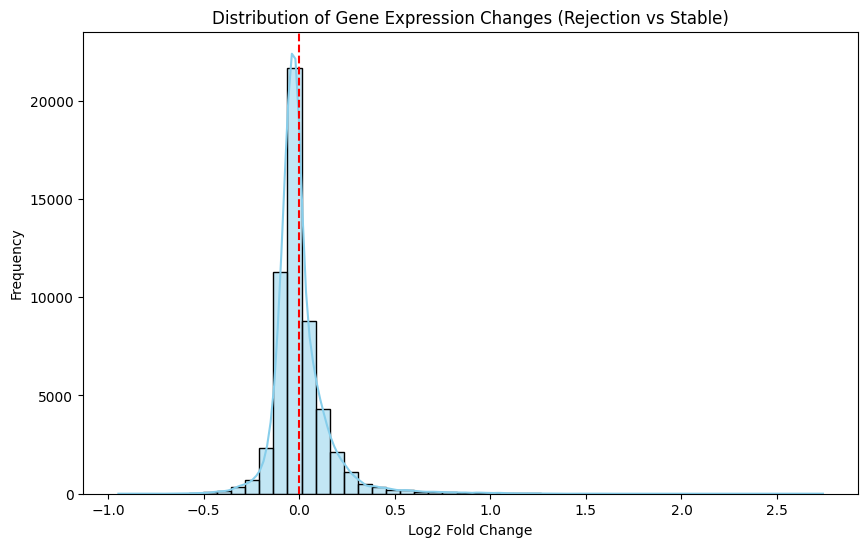

In [29]:
# 10. Visualize the distribution of changes
plt.figure(figsize=(10, 6))
sns.histplot(log2_fc, bins=50, kde=True, color='skyblue')
plt.title('Distribution of Gene Expression Changes (Rejection vs Stable)')
plt.xlabel('Log2 Fold Change')
plt.ylabel('Frequency')
plt.axvline(0, color='red', linestyle='--')
plt.show()

In [31]:
# Map Probe IDs to Gene Symbols
# In GEOparse, platform annotations are stored in the .gpls dictionary
gpl = gse.gpls['GPL570']
gene_metadata = gpl.table[['ID', 'Gene Symbol']]

# Create a dictionary for quick lookup
gene_map = dict(zip(gene_metadata['ID'], gene_metadata['Gene Symbol']))

# Apply the map to Top 50 list
top_biomarkers_named = top_50_genes.copy()
top_biomarkers_named.index = [gene_map.get(i, i) for i in top_50_genes.index]

print("--- TOP 10 CLINICAL BIOMARKERS ---")
print(top_biomarkers_named.head(10))

--- TOP 10 CLINICAL BIOMARKERS ---
CXCL11               2.739844
CXCL11               2.382206
CXCL9                2.286595
CXCL10               2.049447
FAM26F               1.857415
FAM26F               1.613753
IDO1                 1.611146
FCGR3A /// FCGR3B    1.579954
GBP1                 1.554863
GBP1                 1.518534
dtype: float64
